In [1]:
import sys
sys.path.insert(0, "/users/eleves-a/2023/roman.lendormy/reinforcement_learning/Project/RL_project/src")

In [2]:
from mct.train import TrainConfig, run

In [3]:
# cfg = TrainConfig(
#     steps            = 100_000_000,
#     load             = "/Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt",
#     n_envs           = 8,
#     lr               = 5e-5, #ex 3e-4
#     gamma            = 0.995,
#     ent_coef         = 0.03,
#     vf_coef          = 0.25,
#     clip_eps         = 0.1,
#     epochs           = 8,
#     n_steps          = 1024, #ex 512
#     batch            = 4096, #ex 2048
#     gae_lambda       = 0.99, #ex 0.98
#     checkpoint_every = 500_000,
#     checkpoint_dir   = "/Data/roman.lendormy/rl_checkpoints_2",
#     save             = "/Data/roman.lendormy/rl_checkpoints_2/ppo_blockblast.pt",
#     plot             = "/Data/roman.lendormy/rl_checkpoints_2/training_curves.png",
# )
# trainer, history = run(cfg)

# trainer.save("/Data/roman.lendormy/rl_checkpoints_2/ppo_blockblast_final.pt")

In [3]:
import sys
import torch
sys.path.insert(0, "/users/eleves-a/2023/roman.lendormy/reinforcement_learning/Project/RL_project/src")

from mct.train import TrainConfig, run
from mct.ppo_agent import PPOTrainer
from blockblast.block_blast_3p_env import BlockBlast3PEnv

# Recréer un trainer vide puis charger le checkpoint
envs = [BlockBlast3PEnv() for _ in range(1)]  # 1 env factice juste pour init
trainer = PPOTrainer(envs=envs, device=torch.device("cpu"))
trainer.load("/Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt")

Loaded <- /Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt  (step 42,516,480 | mean_ret 164.3 over last 100 eps)


In [5]:
# C'est tout ce qu'il faut — pas de training MCTS
from mct.mcts_agent import compare_ppo_vs_mcts
from blockblast.block_blast_3p_env import BlockBlast3PEnv


In [ ]:

# # trainer est déjà chargé avec ton checkpoint 42.5M steps
# results = compare_ppo_vs_mcts(
#     model      = trainer.model,
#     env_fn     = lambda: BlockBlast3PEnv(),
#     device     = torch.device("cpu"),
#     n_episodes = 100,
# )

--- PPO greedy ---
  Episode   10/100 | return    111.8 | length   23 steps
  Episode   20/100 | return     31.2 | length   14 steps
  Episode   30/100 | return    392.4 | length   34 steps
  Episode   40/100 | return      1.1 | length   11 steps
  Episode   50/100 | return    372.1 | length   29 steps
  Episode   60/100 | return    131.7 | length   20 steps
  Episode   70/100 | return    191.9 | length   23 steps
  Episode   80/100 | return    261.7 | length   23 steps
  Episode   90/100 | return    352.8 | length   38 steps
  Episode  100/100 | return     31.2 | length   14 steps

=== MCTS Evaluation (100 episodes) ===
  Mean return   : 235.58 +/- 203.79
  Median return : 172.00
  Mean length   : 25.1 steps
  Time/round    : 0.0 ms


--- MCTS (depth-3 exhaustive) ---


KeyboardInterrupt: 

In [ ]:
from mct.mcts_agent import MCTSAgent
import torch

agent = MCTSAgent(
    model   = trainer.model,
    device  = torch.device("cpu"),
    gamma   = 0.99,
    verbose = True,  # affiche le score et le temps par round
)

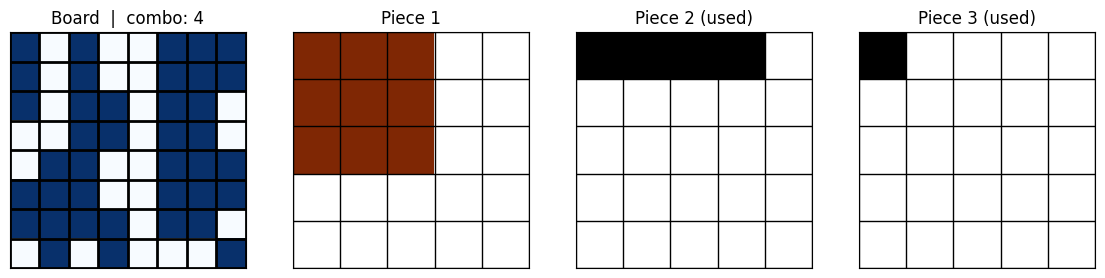


Game Over après 23 steps | Reward finale : 161.6


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

env = BlockBlast3PEnv(render_mode="human")
obs, info = env.reset()

STEPS = 200
total_reward = 0

%matplotlib inline

for step_idx in range(STEPS):
    # Dessiner directement via _draw_figure sans passer par render()
    env._draw_figure()
    
    clear_output(wait=True)
    display(env.fig)
    plt.close(env.fig)
    env.fig = None  # force recréation au prochain step
    
    print(f"Step {step_idx+1} | Combo: {env.combo} | Pieces used: {env.pieces_used.tolist()}")
    print(f"Total reward: {total_reward:.1f}")

    action = agent.select_action(env)
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    time.sleep(0.3)

    if terminated or truncated:
        env._draw_figure()
        clear_output(wait=True)
        display(env.fig)
        plt.close(env.fig)
        env.fig = None
        print(f"\nGame Over après {step_idx+1} steps | Reward finale : {total_reward:.1f}")
        break

env.close()

# Teaching avec MCTS

## Collecte

In [ ]:
trainer.load("/Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt")
trainer.model = trainer.model.to(torch.device("cuda"))

Loaded <- /Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt  (step 42,516,480 | mean_ret 164.3 over last 100 eps)


In [ ]:
from mct.mcts_collect import collect_mcts_dataset

collect_mcts_dataset(
    trainer    = trainer,
    env_fn     = lambda: BlockBlast3PEnv(),
    n_episodes = 1000,
    save_path  = "/Data/roman.lendormy/rl_checkpoints_2/mcts_dataset_v2.npz",
    device     = torch.device("cuda"),
)

  Episode    50/1000 | return    171.6 | len   20 | mean_ret 367.4 | ETA 134.1min
  Episode   100/1000 | return   2057.5 | len  116 | mean_ret 559.4 | ETA 133.6min
  Episode   150/1000 | return    111.4 | len   17 | mean_ret 581.1 | ETA 128.7min
  Episode   200/1000 | return    553.7 | len   53 | mean_ret 578.0 | ETA 118.4min
  Episode   250/1000 | return    372.2 | len   28 | mean_ret 561.7 | ETA 110.6min
  Episode   300/1000 | return    623.0 | len   46 | mean_ret 571.9 | ETA 102.3min
  Episode   350/1000 | return    251.6 | len   20 | mean_ret 573.0 | ETA 94.7min
  Episode   400/1000 | return    151.6 | len   19 | mean_ret 571.7 | ETA 87.5min
  Episode   450/1000 | return    341.9 | len   25 | mean_ret 576.3 | ETA 79.9min
  Episode   500/1000 | return     60.9 | len   11 | mean_ret 577.8 | ETA 72.4min
  Episode   550/1000 | return   1084.8 | len   69 | mean_ret 586.2 | ETA 65.1min
  Episode   600/1000 | return     91.8 | len   22 | mean_ret 579.5 | ETA 58.0min
  Episode   650/1000 |

{'boards': array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 1., 0., 0.],
         [0., 0., 0., ..., 1., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 1., 0., 0.],
         [0., 0., 0., ..., 1., 0., 0.],
         ...,
         [0., 0., 0., ..., 1., 1., 0.],
         [0., 0., 0., ..., 0., 1., 0.],
         [0., 0., 0., ..., 0., 1., 0.]],
 
        ...,
 
        [[1., 1., 1., ..., 0., 1., 1.],
         [0., 0., 0., ..., 0., 1., 1.],
         [0., 0., 0., ..., 0., 1., 1.],
         ...,
         [1., 1., 1., ..., 0., 1., 1.],
         [1., 1., 1., ..., 0.,

In [ ]:
# from mct.ppo_finetune import ppo_finetune_on_mcts

# history = ppo_finetune_on_mcts(
#     trainer      = trainer,
#     dataset_path = "/Data/roman.lendormy/rl_checkpoints_2/mcts_dataset_v2.npz",
#     save_path    = "/Data/roman.lendormy/rl_checkpoints_2/ppo_mcts_ft_v3.pt",
#     device       = torch.device("cuda"),
#     n_epochs     = 5,
#     lr           = 5e-6,    # 10x plus bas
#     clip_eps     = 0.05,    # clipping très serré
#     vf_coef      = 0.1,     # réduire le poids de la VF loss
#     plot_path    = "/Data/roman.lendormy/rl_checkpoints_2/ft_curves_v3.png",
# )

NameError: name 'trainer' is not defined

In [ ]:
import numpy as np
data = np.load("/Data/roman.lendormy/rl_checkpoints_2/mcts_dataset_v2.npz")
print("Rewards min/max/mean:", data["rewards"].min(), data["rewards"].max(), data["rewards"].mean())
print("Dones sum:", data["dones"].sum(), "/ episodes")

Rewards min/max/mean: 0.1 360.0 16.12458
Dones sum: 1000.0 / episodes


In [10]:
from mct.mcts_agent import MCTSAgent
import torch

trainer.model = trainer.model.to(torch.device("cuda"))

agent = MCTSAgent(
    model   = trainer.model,
    device  = torch.device("cuda"),
    gamma   = 0.99,
    verbose = False,)

# PPO greedy
print("--- PPO greedy ---")
ppo_stats = agent.evaluate(
    lambda: BlockBlast3PEnv(),
    n_episodes = 50,
    use_mcts   = False,
)

# MCTS triplet
print("\n--- MCTS triplet ---")
mcts_stats = agent.evaluate(
    lambda: BlockBlast3PEnv(),
    n_episodes = 50,
    use_mcts   = True,
)

# Comparaison
delta = mcts_stats["mean_return"] - ppo_stats["mean_return"]
print(f"\n=== Comparison ===")
print(f"  Return gain   : {delta:+.2f} ({delta/max(abs(ppo_stats['mean_return']),1)*100:+.1f}%)")
print(f"  Length gain   : {mcts_stats['mean_length'] - ppo_stats['mean_length']:+.1f} steps")
print(f"  MCTS overhead : {mcts_stats['mean_time_per_round_ms']:.1f} ms / round")

--- PPO greedy ---
  Episode   10/50 | return    372.0 | length   29 steps
  Episode   20/50 | return    312.3 | length   31 steps
  Episode   30/50 | return    131.5 | length   20 steps
  Episode   40/50 | return   1223.1 | length   46 steps
  Episode   50/50 | return    292.3 | length   29 steps

=== MCTS Evaluation (50 episodes) ===
  Mean return   : 262.19 +/- 243.19
  Median return : 206.75
  Mean length   : 26.8 steps
  Time/round    : 0.0 ms


--- MCTS triplet ---
  Episode   10/50 | return   9322.6 | length  352 steps
  Episode   20/50 | return   9801.1 | length  323 steps
  Episode   30/50 | return   8450.3 | length  314 steps
  Episode   40/50 | return   2527.0 | length  106 steps
  Episode   50/50 | return  13027.2 | length  571 steps

=== MCTS Evaluation (50 episodes) ===
  Mean return   : 6584.07 +/- 5760.61
  Median return : 6099.30
  Mean length   : 222.7 steps
  Time/round    : 246.5 ms


=== Comparison ===
  Return gain   : +6321.88 (+2411.2%)
  Length gain   : +196.0 

In [11]:
import numpy as np

data = np.load("/Data/roman.lendormy/rl_checkpoints_2/mcts_dataset_v2.npz")

# Reconstituer les rewards 3-coups par round
# Dans le dataset, chaque épisode = 35 steps ~= 11-12 rounds de 3 coups
rewards = data["rewards"]
dones   = data["dones"]

# Simuler les cumulative_reward_3steps manuellement
# (grouper par triplets consécutifs dans un épisode)
gamma = 0.99
r3_list = []

i = 0
while i + 2 < len(rewards):
    # vérifier qu'on ne traverse pas une frontière d'épisode
    if dones[i] == 0 and dones[i+1] == 0:
        r3 = rewards[i] + gamma * rewards[i+1] + gamma**2 * rewards[i+2]
        r3_list.append(r3)
        i += 3
    else:
        i += 1

r3 = np.array(r3_list)
print(f"Cumulative 3-step rewards:")
print(f"  min    : {r3.min():.2f}")
print(f"  max    : {r3.max():.2f}")
print(f"  mean   : {r3.mean():.2f}")
print(f"  median : {np.median(r3):.2f}")
print(f"  p75    : {np.percentile(r3, 75):.2f}")
print(f"  p95    : {np.percentile(r3, 95):.2f}")
print(f"\nsymlog de ces valeurs:")
print(f"  min    : {np.sign(r3.min()) * np.log1p(abs(r3.min())):.2f}")
print(f"  max    : {np.sign(r3.max()) * np.log1p(abs(r3.max())):.2f}")
print(f"  mean   : {np.sign(r3.mean()) * np.log1p(abs(r3.mean())):.2f}")

print(f"\nValeur brute PPO (symlog space) : ~14.18")
print(f"Valeur brute PPO (symexp) : ~1.4M")

Cumulative 3-step rewards:
  min    : 0.30
  max    : 564.33
  mean   : 48.32
  median : 29.70
  p75    : 69.70
  p95    : 172.44

symlog de ces valeurs:
  min    : 0.26
  max    : 6.34
  mean   : 3.90

Valeur brute PPO (symlog space) : ~14.18
Valeur brute PPO (symexp) : ~1.4M


In [4]:
# ===== Value weight sweep =====

from mct.value_weight_sweep import run_sweep
from blockblast.block_blast_3p_env import BlockBlast3PEnv
import torch

# S'assurer que le bon checkpoint est chargé
trainer.load("/Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt")
trainer.model = trainer.model.to(torch.device("cuda"))

results = run_sweep(
    model      = trainer.model,
    env_fn     = lambda: BlockBlast3PEnv(),
    device     = torch.device("cuda"),
    n_episodes = 50,
    weights    = [0.0, 0.05, 0.1, 0.3, 0.5, 1.0],
    plot_path  = "/Data/roman.lendormy/rl_checkpoints_2/value_weight_sweep.png",
)

Loaded <- /Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt  (step 42,516,480 | mean_ret 164.3 over last 100 eps)
Value weight sweep — 6 values × 50 episodes

  Weight |   Mean Ret |  Median Ret |  Mean Len |   Std Ret |  ms/round
──────────────────────────────────────────────────────────────────────
  Episode   10/50 | return  27628.8 | length  158 steps
  Episode   20/50 | return   1192.0 | length   34 steps
  Episode   30/50 | return  13618.6 | length  145 steps
  Episode   40/50 | return  10356.1 | length  113 steps
  Episode   50/50 | return   9464.9 | length   91 steps

=== MCTS Evaluation (50 episodes) ===
  Mean return   : 4690.36 +/- 6264.42
  Median return : 2392.85
  Mean length   : 63.7 steps
  Time/round    : 907.6 ms

   0.000 |    4690.36 |     2392.85 |      63.7 |   6264.42 |     907.6
  Episode   10/50 | return  54285.3 | length  292 steps
  Episode   20/50 | return  14786.7 | length  121 steps
  Episode   30/50 | return   2643.9 | length   68 steps
  Episode   40/

In [ ]:
from mct.mcts_agent import compare_ppo_vs_mcts

results = compare_ppo_vs_mcts(
    model      = trainer.model,
    env_fn     = lambda: BlockBlast3PEnv(),
    device     = torch.device("cuda"),
    n_episodes = 50,
)

--- PPO greedy ---
  Episode   10/50 | return    372.3 | length   32 steps
  Episode   20/50 | return     71.5 | length   17 steps
  Episode   30/50 | return    552.2 | length   32 steps
  Episode   40/50 | return   1223.6 | length   56 steps
  Episode   50/50 | return     61.1 | length   14 steps

=== MCTS Evaluation (50 episodes) ===
  Mean return   : 265.09 +/- 244.32
  Median return : 172.45
  Mean length   : 25.5 steps
  Time/round    : 0.0 ms


--- MCTS (depth-3 exhaustive) ---
  Episode   10/50 | return    212.0 | length   29 steps
  Episode   20/50 | return    883.6 | length   53 steps
  Episode   30/50 | return     41.3 | length   16 steps
  Episode   40/50 | return    662.1 | length   32 steps
  Episode   50/50 | return   2437.0 | length  110 steps

=== MCTS Evaluation (50 episodes) ===
  Mean return   : 448.46 +/- 541.76
  Median return : 271.90
  Mean length   : 31.9 steps
  Time/round    : 854.2 ms


=== Comparison ===
  Return gain   : +183.37  (+69.2%)
  Length gain   : 

# PPO online with MCTS

In [4]:
from mct.mcts_ppo_trainer import MCTSPPOTrainer
from blockblast.block_blast_3p_env import BlockBlast3PEnv
import torch, os

os.makedirs("/Data/roman.lendormy/rl_checkpoints_2/mcts_ppo", exist_ok=True)

# 4 envs suffit — le goulot d'étranglement est MCTS pas le GPU
envs = [BlockBlast3PEnv() for _ in range(4)]

mcts_trainer = MCTSPPOTrainer(
    envs       = envs,
    device     = torch.device("cuda"),
    lr         = 1e-4,
    n_steps    = 128,
    n_epochs   = 4,
    batch_size = 256,
    ent_coef   = 0.01,
    vf_coef    = 0.25,
    gae_lambda = 0.98,
    gamma      = 0.99,
)

# Charger le checkpoint original comme point de départ
mcts_trainer.load("/Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt")
mcts_trainer.model = mcts_trainer.model.to(torch.device("cuda"))

Loaded <- /Data/roman.lendormy/rl_checkpoints_2/ckpt_42516k.pt  (step 42,516,480 | mean_ret 164.3 over last 100 eps)


In [5]:
history = mcts_trainer.train(
    total_timesteps  = 5_000_000,
    log_interval     = 1,
    checkpoint_every = 500_000,
    checkpoint_dir   = "/Data/roman.lendormy/rl_checkpoints_2/mcts_ppo",
)


MCTS-PPO — 5,000,000 steps · 9765 updates · 4 envs

  Upd |      Steps |   MeanRet |    MedRet |  MeanLen |   PgLoss |   VfLoss |  Entropy |  ClipFr |    Time
──────────────────────────────────────────────────────────────────────────────────────────────────────────
    1 | 42,516,992 |    229.21 |    141.70 |     23.9 |   0.0072 | 282.2305 |   1.0698 |   0.082 |    252s
    2 | 42,517,504 |    312.23 |    166.75 |     26.1 |   0.0161 | 348.5758 |   1.1115 |   0.147 |    231s
    3 | 42,518,016 |    354.04 |    211.70 |     28.0 |   0.0223 | 198.8566 |   1.0112 |   0.142 |    344s
    4 | 42,518,528 |    421.56 |    256.95 |     30.0 |   0.0330 | 148.7586 |   0.8608 |   0.166 |    277s
    5 | 42,519,040 |    461.46 |    277.00 |     31.6 |   0.0051 | 169.0176 |   0.8960 |   0.122 |    332s
    6 | 42,519,552 |    503.39 |    281.95 |     32.6 |   0.0591 | 175.2590 |   0.8564 |   0.123 |    212s
    7 | 42,520,064 |    503.89 |    286.90 |     32.6 |   0.0439 | 200.1769 |   0.9333 |   

KeyboardInterrupt: 